In [75]:
import pandas as pd
df=pd.read_csv("archive (2).zip")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [76]:
df.shape

(891, 12)

In [77]:
df.rename(columns={'Sex':'Gender'},inplace=True)

In [78]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Gender           0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [79]:
df.drop('Cabin',axis=1,inplace=True)

In [80]:
df['Age']

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888     NaN
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

In [81]:
df['Age'].mean()

np.float64(29.69911764705882)

In [82]:
df['Age'].median()

28.0

In [83]:
df['Age']=df['Age'].fillna(df['Age'].median())

In [84]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Gender         0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
dtype: int64

In [85]:
df['Embarked']

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: object

In [86]:
df['Embarked'].value_counts()


Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [87]:
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])

In [88]:
df.isnull().sum()


PassengerId    0
Survived       0
Pclass         0
Name           0
Gender         0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [89]:
df['Embarked'].mode()

0    S
Name: Embarked, dtype: object

Survival rate by gender?

In [90]:
#df.groupby('col_name')['target_col'].operation()

#Survival rate by gender?
df.groupby('Gender')['Survived'].mean()

Gender
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [91]:
df.groupby('Gender')['Survived'].mean().round(2)

Gender
female    0.74
male      0.19
Name: Survived, dtype: float64

Average age by passanger class

In [92]:
df.groupby('Pclass')['Age'].mean()

Pclass
1    36.812130
2    29.765380
3    25.932627
Name: Age, dtype: float64

In [93]:
df['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

Survival count by Emabarked

In [94]:
df.groupby('Embarked')['Survived'].sum()

Embarked
C     93
Q     30
S    219
Name: Survived, dtype: int64

In [95]:
df.groupby('Embarked')['Survived'].count()

Embarked
C    168
Q     77
S    646
Name: Survived, dtype: int64

In [96]:
df.groupby('Embarked')['Survived'].count() - df.groupby('Embarked')['Survived'].sum()

Embarked
C     75
Q     47
S    427
Name: Survived, dtype: int64

Merge

In [97]:
df1=pd.DataFrame({'sid':[401,402,403,405],
                  'name':['Monu','Moni','Monika','Pavu'],
                  'city':['tmk','Bng','Hsn','Mysore']
                 })
df1

,sid,name,city
0,401,Monu,tmk
1,402,Moni,Bng
2,403,Monika,Hsn
3,405,Pavu,Mysore


In [98]:
df2=pd.DataFrame({'sid':[401,402,403,405],'marks':[65,78,92,88]})
df2

,sid,marks
0,401,65
1,402,78
2,403,92
3,405,88


In [99]:
final_df=pd.merge(df1,df2,on='sid')
final_df

,sid,name,city,marks
0,401,Monu,tmk,65
1,402,Moni,Bng,78
2,403,Monika,Hsn,92
3,405,Pavu,Mysore,88


In [100]:
left_join=pd.merge(df1,df2,on='sid',how='right')
left_join

,sid,name,city,marks
0,401,Monu,tmk,65
1,402,Moni,Bng,78
2,403,Monika,Hsn,92
3,405,Pavu,Mysore,88


In [101]:
right_join=pd.merge(df1,df2,on='sid',how='right')
right_join

,sid,name,city,marks
0,401,Monu,tmk,65
1,402,Moni,Bng,78
2,403,Monika,Hsn,92
3,405,Pavu,Mysore,88


In [102]:
full_join=pd.merge(df1,df2,on='sid',how='right')
full_join

,sid,name,city,marks
0,401,Monu,tmk,65
1,402,Moni,Bng,78
2,403,Monika,Hsn,92
3,405,Pavu,Mysore,88


Concatenation

In [103]:
df3=pd.DataFrame({'sid':[510,512,513],
                  'name':['Sannu','Munnu','Manu'],
                  'city':['Delhi','Mumbai','Hydrabad']
                 })
df3

,sid,name,city
0,510,Sannu,Delhi
1,512,Munnu,Mumbai
2,513,Manu,Hydrabad


In [104]:
df_combine=pd.concat([df1,df3])
df_combine

,sid,name,city
0,401,Monu,tmk
1,402,Moni,Bng
2,403,Monika,Hsn
3,405,Pavu,Mysore
0,510,Sannu,Delhi
1,512,Munnu,Mumbai
2,513,Manu,Hydrabad


In [105]:
df_combine=pd.concat([df1,df3],ignore_index=True)
df_combine

,sid,name,city
0,401,Monu,tmk
1,402,Moni,Bng
2,403,Monika,Hsn
3,405,Pavu,Mysore
4,510,Sannu,Delhi
5,512,Munnu,Mumbai
6,513,Manu,Hydrabad


In [106]:
df1_df2=pd.concat([df1,df2],ignore_index=True)
df1_df2

,sid,name,city,marks
0,401,Monu,tmk,NaN
1,402,Moni,Bng,NaN
2,403,Monika,Hsn,NaN
3,405,Pavu,Mysore,NaN
4,401,NaN,NaN,65.0
5,402,NaN,NaN,78.0
6,403,NaN,NaN,92.0
7,405,NaN,NaN,88.0


In [107]:
#data time functions
from datetime import datetime
present=datetime.now()
print(present)

2026-02-20 10:38:29.968250


In [108]:
print(present.year)
print(present.hour)
print(present.month)
print(present.minute)

2026
10
2
38


In [109]:
dob="2004-03-07"
print(type(dob))
obj=datetime.strptime(dob,"%Y-%M-%d")
print(obj)
print(type(obj))

<class 'str'>
2004-01-07 00:03:00
<class 'datetime.datetime'>


In [110]:
print(type(present))
#convert date into str
str_obj=present.strftime("%Y-%M-%d")
print(str_obj)
print(type(str_obj))

<class 'datetime.datetime'>
2026-38-20
<class 'str'>


In [111]:
df=pd.DataFrame({'name':['Sannu','Munnu','Manu'],
                  'DOB':['2002-11-6','2005-10-6','2004-3-7']
                 })
df

,name,DOB
0,Sannu,2002-11-6
1,Munnu,2005-10-6
2,Manu,2004-3-7


In [112]:
df['DOB'].dtype

dtype('O')

In [113]:
df['DOB']=pd.to_datetime(df['DOB'])
df['DOB'].dtype

dtype('<M8[ns]')

In [114]:
df['year']=df['DOB'].dt.year
df

,name,DOB,year
0,Sannu,2002-11-06,2002
1,Munnu,2005-10-06,2005
2,Manu,2004-03-07,2004


In [115]:
df['week_day']=df['DOB'].dt.day_name()

In [116]:
df['week_num']=df['DOB'].dt.weekday
df

,name,DOB,year,week_day,week_num
0,Sannu,2002-11-06,2002,Wednesday,2
1,Munnu,2005-10-06,2005,Thursday,3
2,Manu,2004-03-07,2004,Sunday,6


Seaborn

In [119]:
import pandas as pd
df=pd.read_csv("archive (2).zip")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<Axes: xlabel='Survived', ylabel='count'>

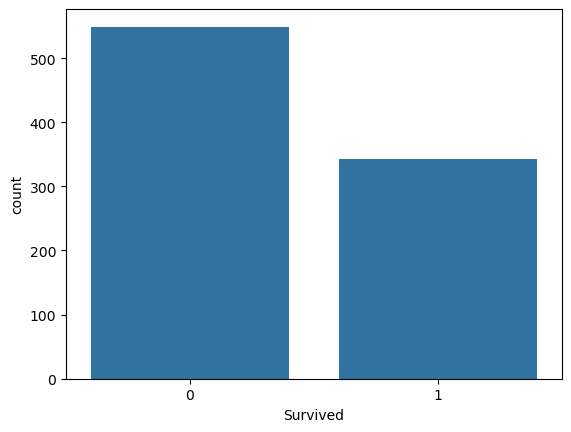

In [120]:
import seaborn as sns
sns.countplot(x='Survived',data=df)

<Axes: xlabel='Sex', ylabel='count'>

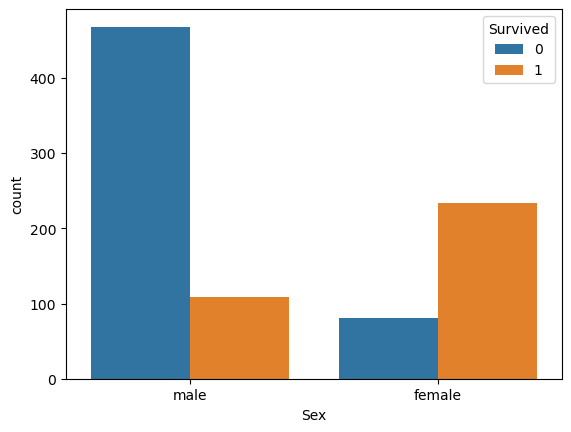

In [122]:
sns.countplot(x='Sex',hue='Survived',data=df)

In [123]:
df['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [124]:
df.groupby('Sex')['Survived'].sum()

Sex
female    233
male      109
Name: Survived, dtype: int64

In [125]:
df.corr(numeric_only=True)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


In [126]:
df.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


In [127]:
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [128]:
df.corr(numeric_only=True)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


In [129]:
sns.heatmap(res,annot=True,cmap='coolwarm')

NameError: name 'res' is not defined

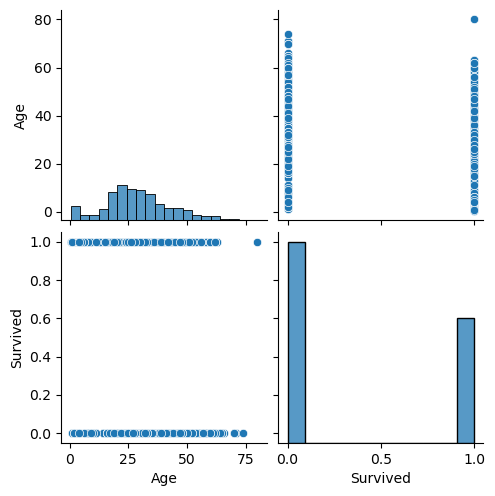

In [130]:
sns.pairplot(df[['Age','Survived']])

In [135]:
df.head()
df['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [138]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Sex']=le.fit_transform(df['Sex'])
df['Sex'].value_counts()

Sex
1    577
0    314
Name: count, dtype: int64

In [139]:
df.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C


In [142]:
df.drop(['PassengerId','Name','Ticket'],axis=1)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,1,22.0,1,0,7.2500,NaN,S
1,1,1,0,38.0,1,0,71.2833,C85,C
2,1,3,0,26.0,0,0,7.9250,NaN,S
3,1,1,0,35.0,1,0,53.1000,C123,S
4,0,3,1,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.0,0,0,13.0000,NaN,S
887,1,1,0,19.0,0,0,30.0000,B42,S
888,0,3,0,NaN,1,2,23.4500,NaN,S
889,1,1,1,26.0,0,0,30.0000,C148,C


In [141]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,S


In [143]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [144]:
from sklearn.preprocessing import OrdinalEncoder
oe=OrdinalEncoder()
df['Embarked']=oe.fit_transform(df[['Embarked']])
df['Embarked'].value_counts()

Embarked
2.0    644
0.0    168
1.0     77
Name: count, dtype: int64

Feature Scaling

In [4]:
#Feature scaling it brings value in similar range
import pandas as pd
data=pd.DataFrame({'Year':[2007,2007,2012,2017,2014],
                    'Selling price':[60000,135000,600000,250000,450000],
                    'Km_driven':[70000,50000,100000,46000,141000]})
data

,Year,Selling price,Km_driven
0,2007,60000,70000
1,2007,135000,50000
2,2012,600000,100000
3,2017,250000,46000
4,2014,450000,141000


In [5]:
data.head()

,Year,Selling price,Km_driven
0,2007,60000,70000
1,2007,135000,50000
2,2012,600000,100000
3,2017,250000,46000
4,2014,450000,141000


In [7]:
from sklearn.preprocessing import MinMaxScaler
mx = MinMaxScaler()
data['Year'] = mx.fit_transform(data[['Year']])